# Analysis: 20260612

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
from cdk.analysis.cytosol import platereader as pr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Filter warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
data, platemap = pr.load_platereader_data("./data/20250612-cytation3-pure-timecourse-gfp-ppk-biotek-cdk.txt", "20250612-PPK.csv")

# Well A23 (CP + PolyP + 8 mM Mg, replicate 3/3) fits to k~=0 (degenerate/non-responding), which crashes kinetic_analysis's lag-time calculation. Drop it; keep A19/A21 (its two other replicates).
data_drop = data[data["Well"] != "A23"]

# Basic Plots

## Kinetics 
Kinetic time traces of every well on the plate

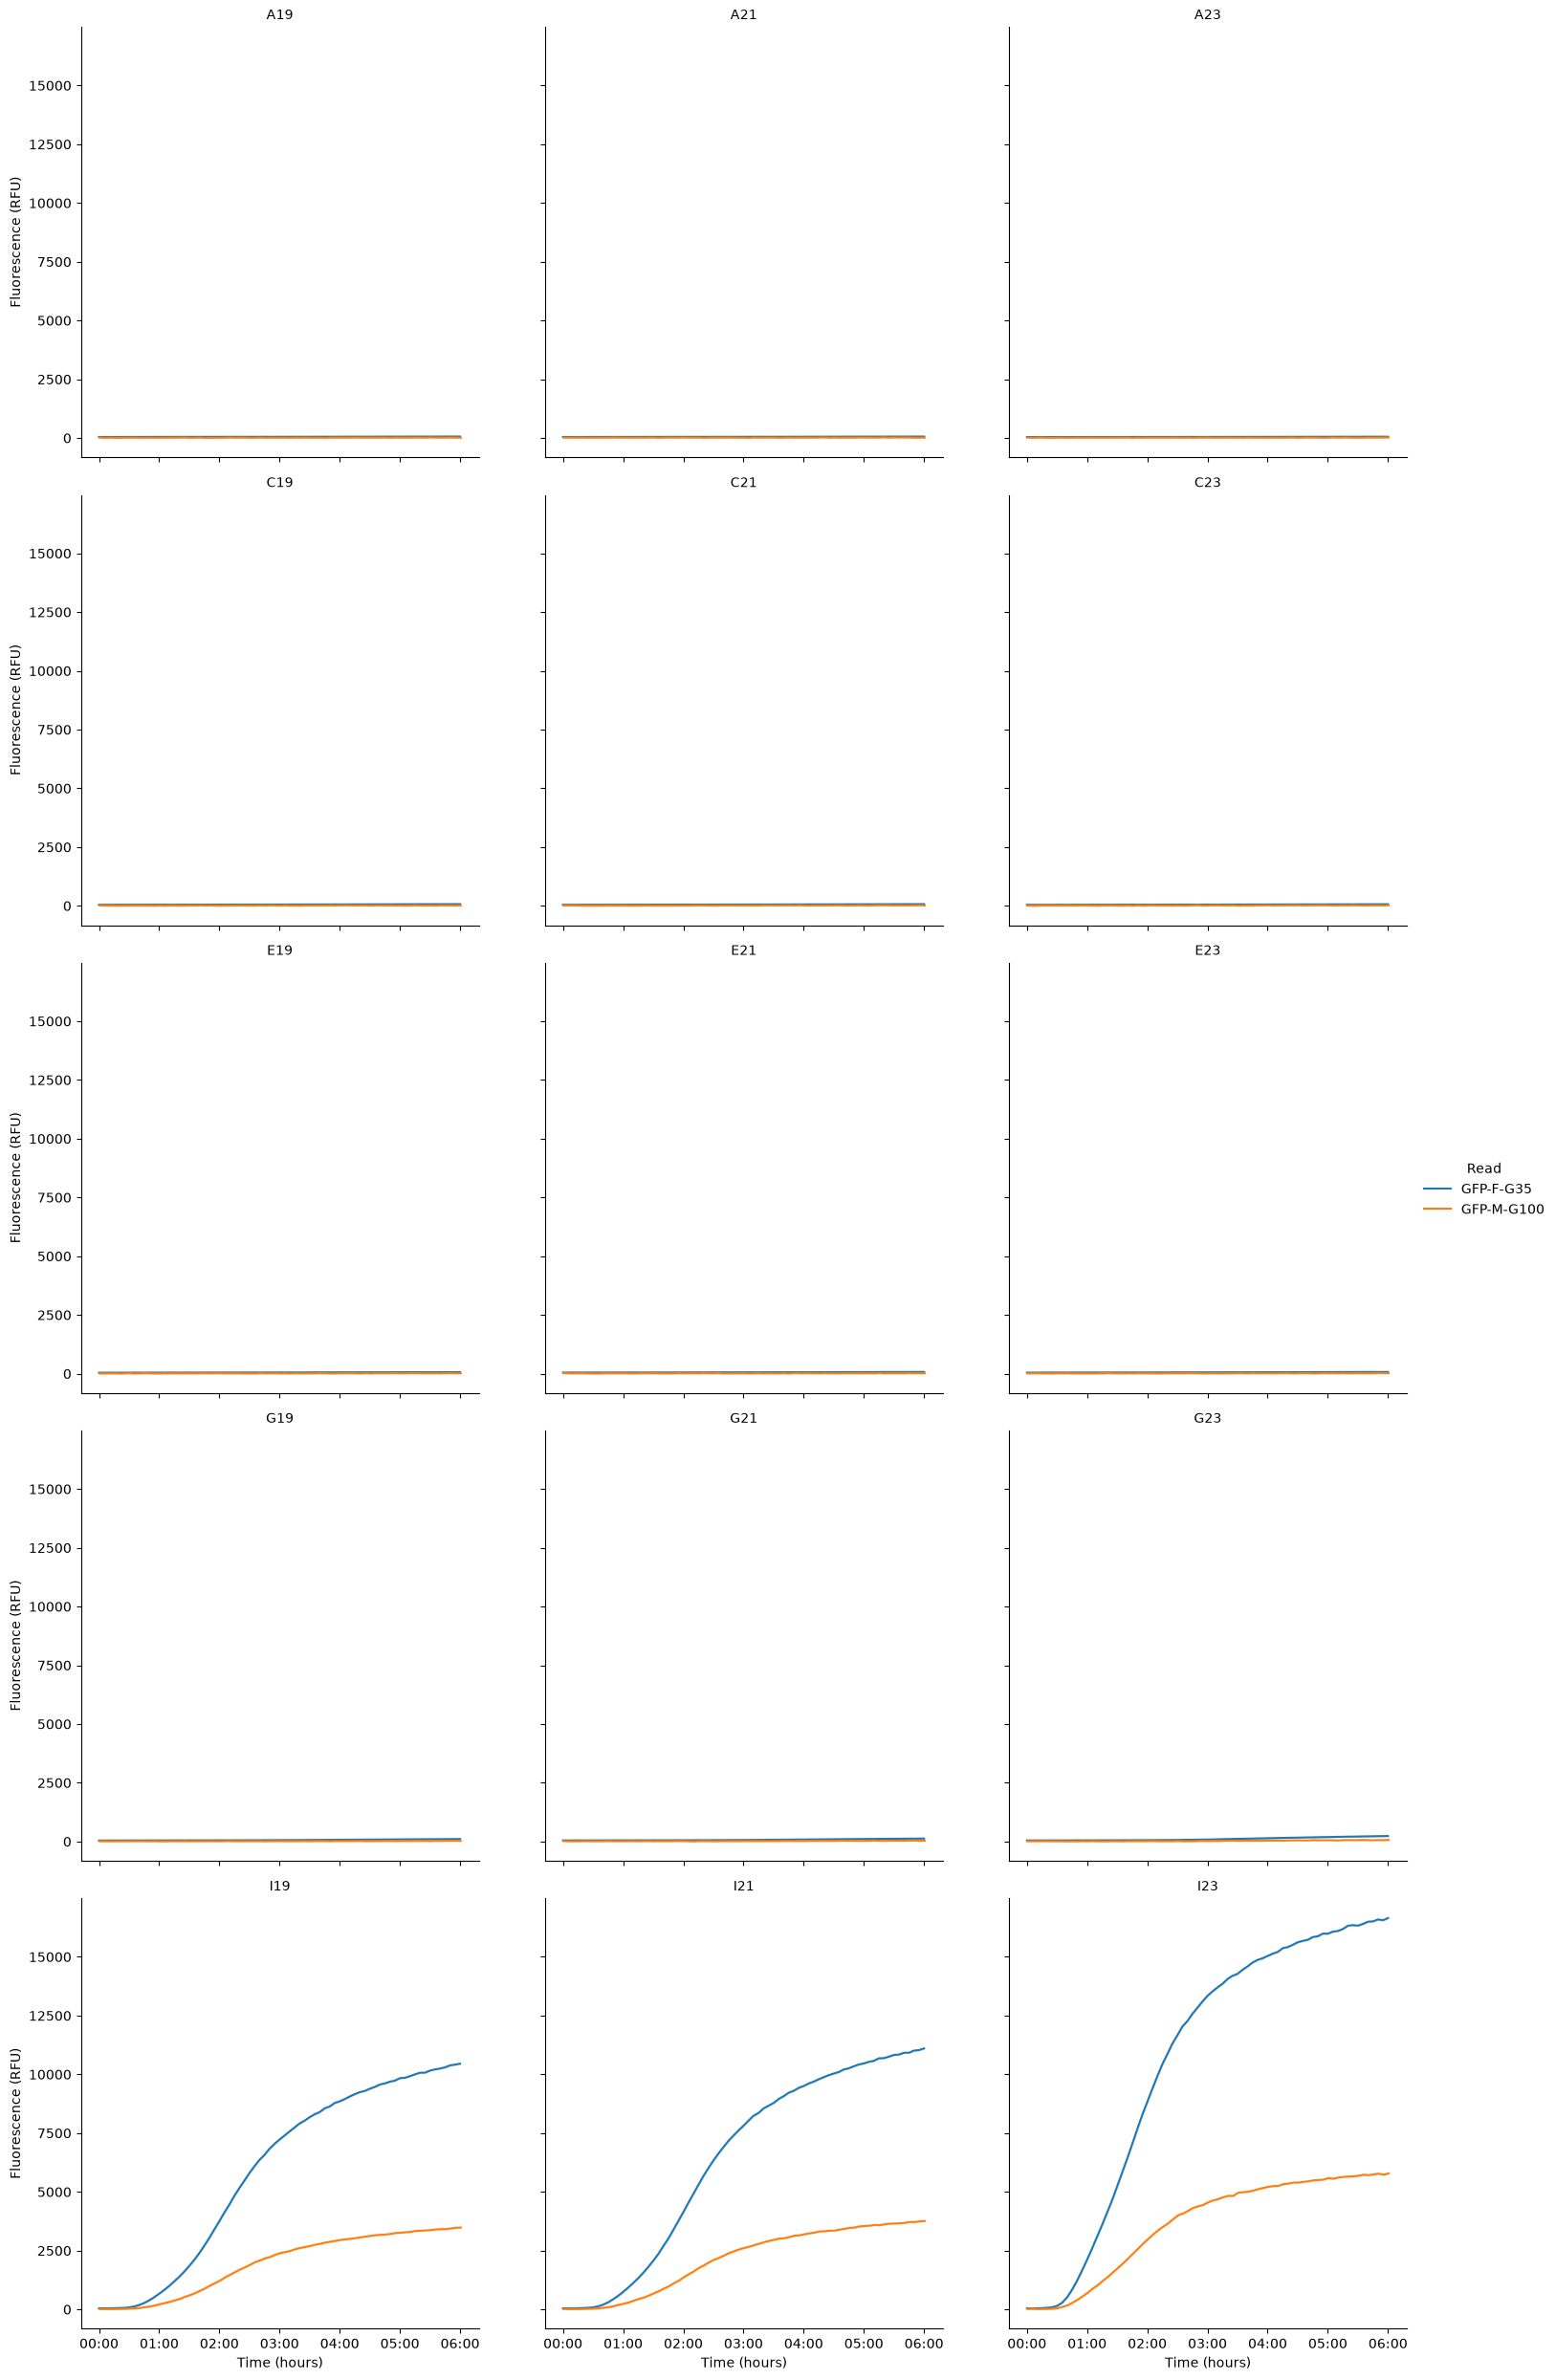

In [4]:
pr.plot_plate(data);

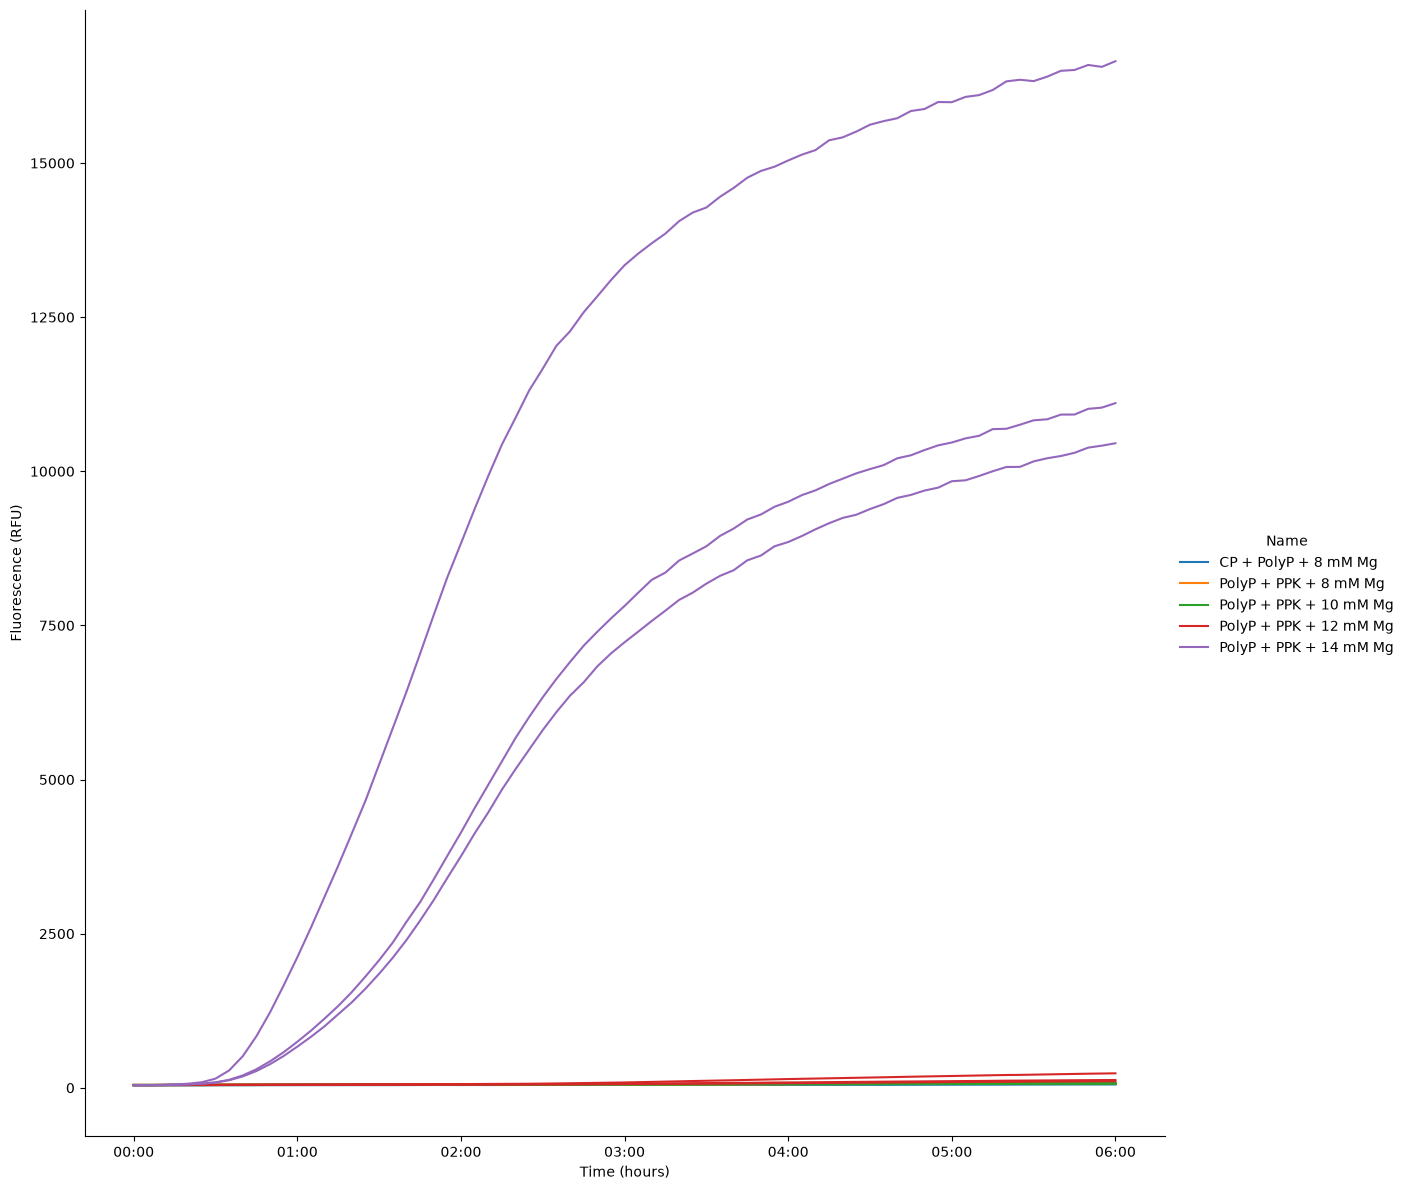

In [5]:
g = pr.plot_curves(data[data["Read"]=="GFP-F-G35"], units="Well", estimator=None, height=12)
g.savefig("plot4")

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

<Axes: xlabel='Name', ylabel='Data_steadystate'>

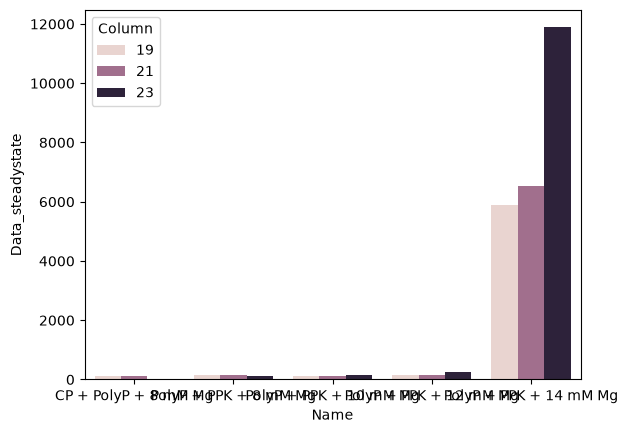

In [6]:
ss = pr.find_steady_state(data_drop[data_drop["Read"]=="GFP-F-G35"], group_by=["Well", "Read"]).reset_index()
ss.columns = [c[0] if c[1] == "" else "_".join(c).strip() for c in ss.columns]
steadystate = data_drop.merge(ss[["Well", "Data_steadystate"]], on="Well", how="left")
steadystate.loc[steadystate["Column"]==13, "Column"] = 14
sns.barplot(data=steadystate, x="Name", y="Data_steadystate", hue="Column")

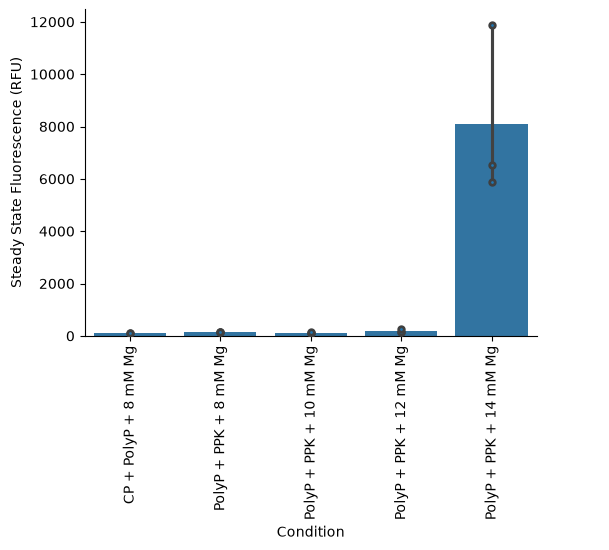

In [7]:
#| label: fig:endpoint-exp3

ss= pr.plot_steadystate(data_drop[data_drop["Read"]=="GFP-F-G35"])
plt.xlabel('Condition')
ss.savefig("plot5")

# Kinetics Analysis
These functions calculate key kinetic parameters of the time series.

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x313d29d10>,
                                                   Velocity                  \
                                                       Time    Data     Max   
 Name                   Read                                                  
 CP + PolyP + 8 mM Mg   GFP-F-G35 0 days 00:31:47.660537468   61.11    0.01   
 PolyP + PPK + 10 mM Mg GFP-F-G35 0 days 04:00:52.708004714   67.14    5.22   
 PolyP + PPK + 12 mM Mg GFP-F-G35 0 days 04:30:17.546196339  101.75   38.93   
 PolyP + PPK + 14 mM Mg GFP-F-G35 0 days 02:01:24.172850169 4264.55 4639.04   
 PolyP + PPK + 8 mM Mg  GFP-F-G35 0 days 05:56:29.344611142   71.35    6.96   
 
                                                            Lag            \
                                                           Time      Data   
 Name                   Read                                                
 CP + PolyP + 8 mM Mg   GFP-F-G35 -268 days +14:55:51.859371432 -18940.22   
 PolyP + PPK

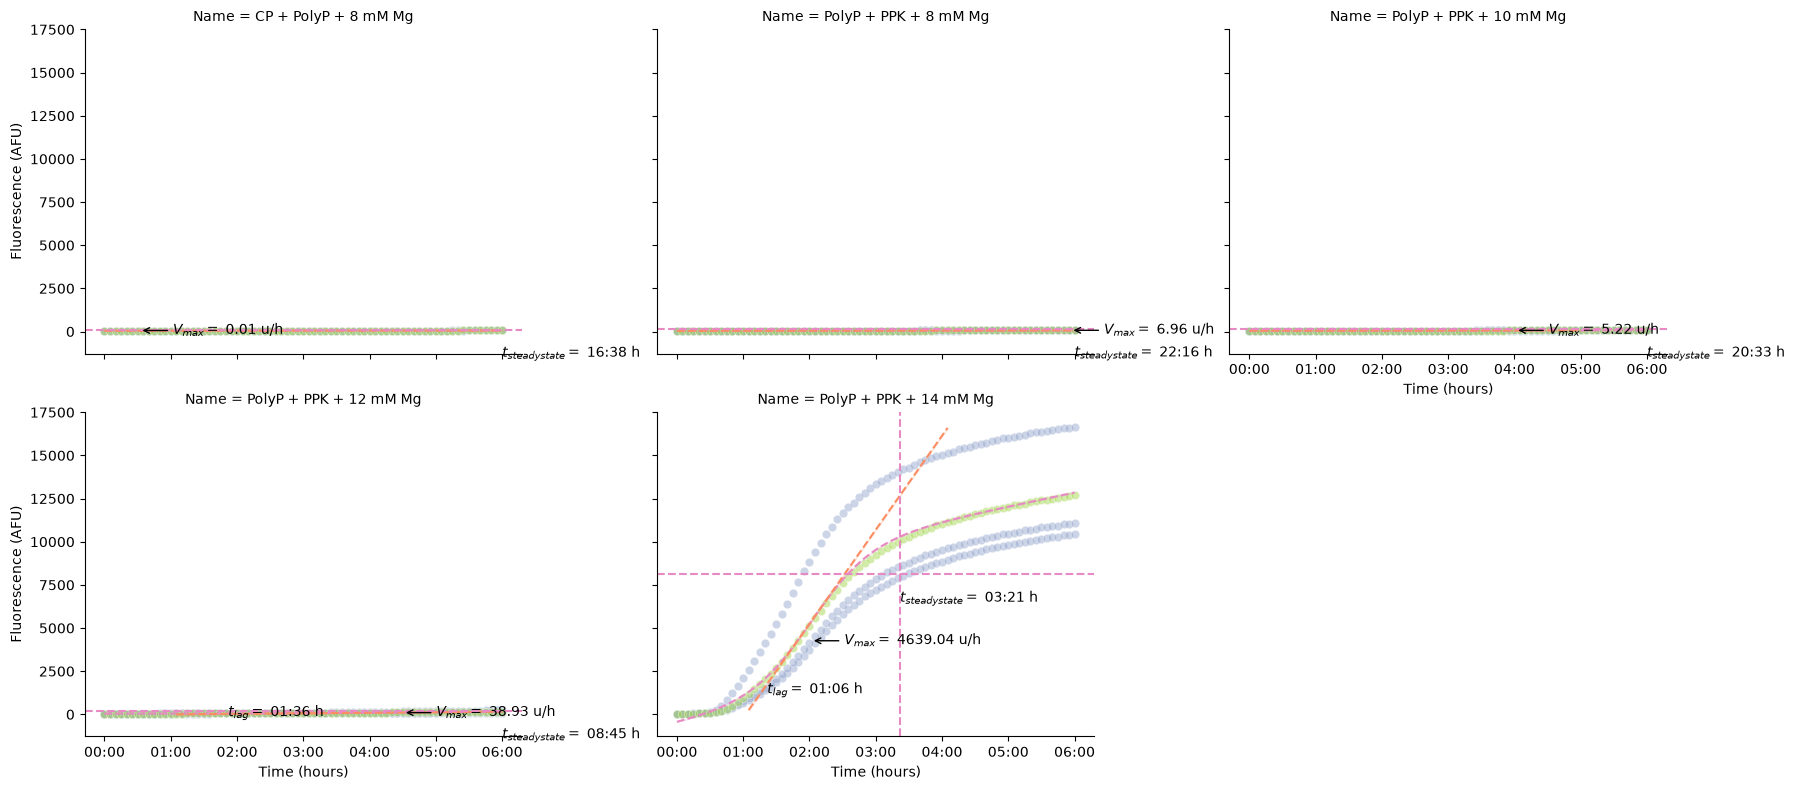

In [8]:
pr.plot_kinetics(data_drop[data_drop["Read"] == "GFP-F-G35"])

We can also calculate the kinetics and display the parameters as a table.

In [9]:
pr.kinetic_analysis(data_drop)

Velocity          \
                                                            Time    Data   
Name                   Read       Well                                     
CP + PolyP + 8 mM Mg   GFP-F-G35  A19  0 days 01:03:26.812160974   61.24   
                                  A21  0 days 00:00:08.508913963   60.98   
PolyP + PPK + 8 mM Mg  GFP-F-G35  C19  0 days 05:49:28.033833428   71.33   
                                  C21            0 days 06:00:00   73.65   
                                  C23            0 days 06:00:00   69.07   
PolyP + PPK + 10 mM Mg GFP-F-G35  E19  0 days 05:38:26.536823289   63.71   
                                  E21  0 days 05:06:50.009002509   65.70   
                                  E23  0 days 01:17:21.578188344   72.01   
PolyP + PPK + 12 mM Mg GFP-F-G35  G19  0 days 04:51:27.631001404   82.45   
                                  G21  0 days 04:28:49.219922409   86.79   
                                  G23  0 days 04:10:35.787665204  136.00   
PolyP + PPK + 14 mM Mg GFP-F-G35  I19  0 days 02:10:49.103983599 3094.87   
                                  I21  0 days 02:08:44.211907744 3445.48   
                                  I23  0 days 01:44:39.202659164 6253.30   
CP + PolyP + 8 mM Mg   GFP-M-G100 A19  0 days 04:10:25.869873406   12.06   
                                  A21  0 days 04:10:22.950343736   11.81   
PolyP + PPK + 8 mM Mg  GFP-M-G100 C19  0 days 01:38:01.739382572   10.59   
                                  C21  0 days 03:01:29.768717816   32.93   
                                  C23  0 days 02:11:06.202328157   21.42   
PolyP + PPK + 10 mM Mg GFP-M-G100 E19  0 days 00:36:43.660533038   16.81   
                                  E21  0 days 00:00:12.798313052   18.89   
                                  E23  0 days 05:57:47.359074045   21.79   
PolyP + PPK + 12 mM Mg GFP-M-G100 G19  0 days 06:00:38.000000001   30.70   
                                  G21  0 days 03:52:33.827539015   21.12   
                                  G23  0 days 04:06:13.008321262   50.87   
PolyP + PPK + 14 mM Mg GFP-M-G100 I19  0 days 02:12:39.938167854 1037.34   
                                  I21  0 days 02:10:37.511189475 1126.94   
                                  I23  0 days 01:47:04.364371449 2132.02   

                                                                         Lag  \
                                           Max                          Time   
Name                   Read       Well                                         
CP + PolyP + 8 mM Mg   GFP-F-G35  A19     0.01 -388 days +21:51:28.491050520   
                                  A21     0.02 -148 days +08:00:15.227692344   
PolyP + PPK + 8 mM Mg  GFP-F-G35  C19     4.51   -1 days +13:59:42.997701491   
                                  C21     8.68   -1 days +21:30:51.727233435   
                                  C23     7.71   -1 days +21:02:10.787216687   
PolyP + PPK + 10 mM Mg GFP-F-G35  E19     6.62   -1 days +20:01:19.937048376   
                                  E21     9.03   -1 days +21:50:26.836279718   
                                  E23     0.00 -612 days +00:45:10.497166056   
PolyP + PPK + 12 mM Mg GFP-F-G35  G19    23.08     0 days 01:17:05.390478520   
                                  G21    28.98     0 days 01:29:06.116766478   
                                  G23    64.74     0 days 02:04:33.349952992   
PolyP + PPK + 14 mM Mg GFP-F-G35  I19  3486.61     0 days 01:17:33.583588461   
                                  I21  3815.70     0 days 01:14:33.496479139   
                                  I23  6614.81     0 days 00:47:55.946332492   
CP + PolyP + 8 mM Mg   GFP-M-G100 A19     3.19     0 days 00:23:42.347738140   
                                  A21     4.01     0 days 01:13:37.125227888   
PolyP + PPK + 8 mM Mg  GFP-M-G100 C19     2.28   -1 days +20:58:55.761360881   
                                  C21     8.20   -1 days +23:00:23.028757636   
                   